In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

def set_context(fig_size = (21.7,21.27), contx = 'paper', axes_style = 'darkgrid'):
    sns.set_style("darkgrid")
    sns.set_context(contx)
    sns.set_theme(rc={'figure.figsize':fig_size}) #width - height
    sns.axes_style(axes_style)
    return 0

set_context(fig_size = (16,11), contx = 'talk')

0

In [2]:
spei_csv = '/home/politti/data/Danube_5min/spei_nuts_2/nuts_2_spei.csv'
df = pd.read_csv(spei_csv)
df = df[df['scenario'].isin(['validation', 'historical'])]
df.head()

,date,shp_id,year,month,scenario,gcm,NUTS_ID,NAME_LATIN,CNTR_CODE,water_balance,spei3,spei12,spei3_dry,spei12_dry
0,1951-01-16 00:00:00,6.0,1951,1,validation,cru,AT11,NaN,AT,1898.1001,NaN,NaN,0,0
1,1951-02-15 00:00:00,6.0,1951,2,validation,cru,AT11,NaN,AT,1227.2000,NaN,NaN,0,0
2,1951-03-16 00:00:00,6.0,1951,3,validation,cru,AT11,NaN,AT,3008.4000,1.11,NaN,0,0
3,1951-04-16 00:00:00,6.0,1951,4,validation,cru,AT11,NaN,AT,-2708.2998,0.93,NaN,0,0
4,1951-05-16 00:00:00,6.0,1951,5,validation,cru,AT11,NaN,AT,2246.9000,0.96,NaN,0,0


In [3]:
def plot_cumulative_spei(df, x_col='spei3', hue_col='scenario'):
    """
    Plots the cumulative probability of a continuous variable,
    calculated independently for each category.
    """
    # Initialize the plot size
    plt.figure(figsize=(10, 6))

    # Create the Empirical Cumulative Distribution plot
    sns.ecdfplot(
        data=df,
        x=x_col,
        hue=hue_col,
        linewidth=2
    )

    # Formatting the plot
    plt.title(f'Cumulative Probability of {x_col.upper()} by Scenario', fontsize=14)
    plt.xlabel(f'{x_col.upper()}', fontsize=12)
    plt.ylabel('Cumulative Probability', fontsize=12)

    # Add a grid for easier reading of probability thresholds
    plt.grid(True, linestyle='--', alpha=0.6)

    # Display the plot
    plt.tight_layout()
    plt.show()


def plot_timeseries_spei(df, x_col='date', y_col='spei3', hue_col='scenario', start_year = None, end_year = None):
    """
    Plots a timeseries lineplot of a continuous variable (SPEI-3)
    categorized by scenario.
    """
    if start_year is not None and end_year is not None:
        df = df[(df['year'] >= start_year ) & (df['year'] <= end_year)]


    # 1. Initialize the plot size (wider is better for timeseries)
    plt.figure(figsize=(12, 6))

    # 2. Create the Line Plot
    # By default, if there are multiple values for the same date/scenario,
    # seaborn will plot the mean and show a shaded confidence interval.
    sns.lineplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=hue_col,
        linewidth=1.5,
        alpha=0.8 # Slight transparency helps when lines overlap
    )

    # 3. Add a critical reference line at 0 (Normal conditions)
    plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5, label='Normal (SPEI = 0)')

    # Optional: Add faint red/blue background spans for extreme drought/wetness
    # plt.axhspan(-2, -3, color='red', alpha=0.1, label='Extreme Drought (SPEI < -2)')

    # 4. Formatting the plot
    plt.title('SPEI-3 Timeseries Projections by Scenario', fontsize=15, pad=15)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('SPEI-3', fontsize=12)

    # Rotate date labels so they don't overlap
    plt.xticks(rotation=45)

    # Ensure the legend doesn't cover the data
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)

    # 5. Display
    plt.tight_layout()
    plt.show()

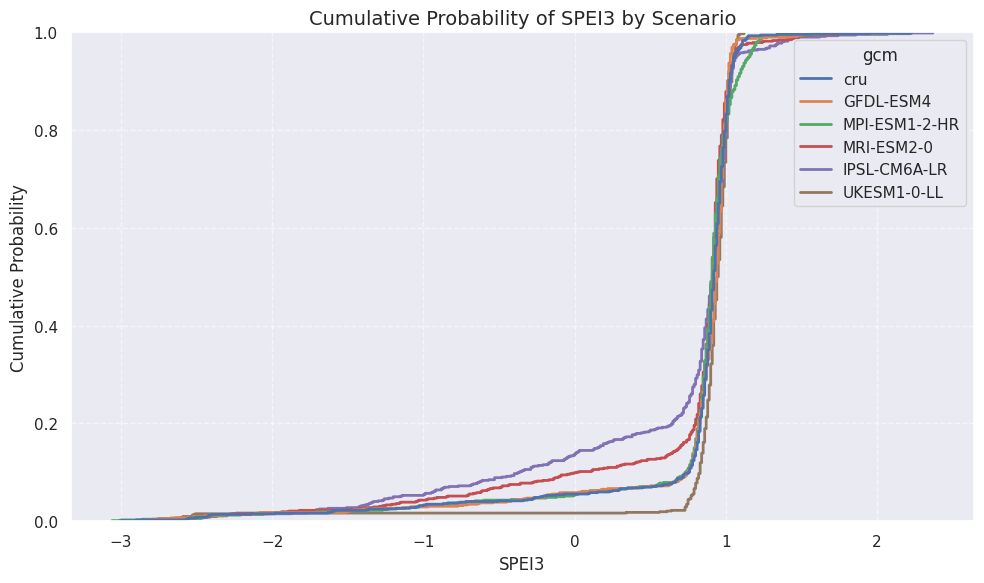

In [4]:
plot_cumulative_spei(df,
                     x_col='spei3',
                     hue_col='gcm'
                     )

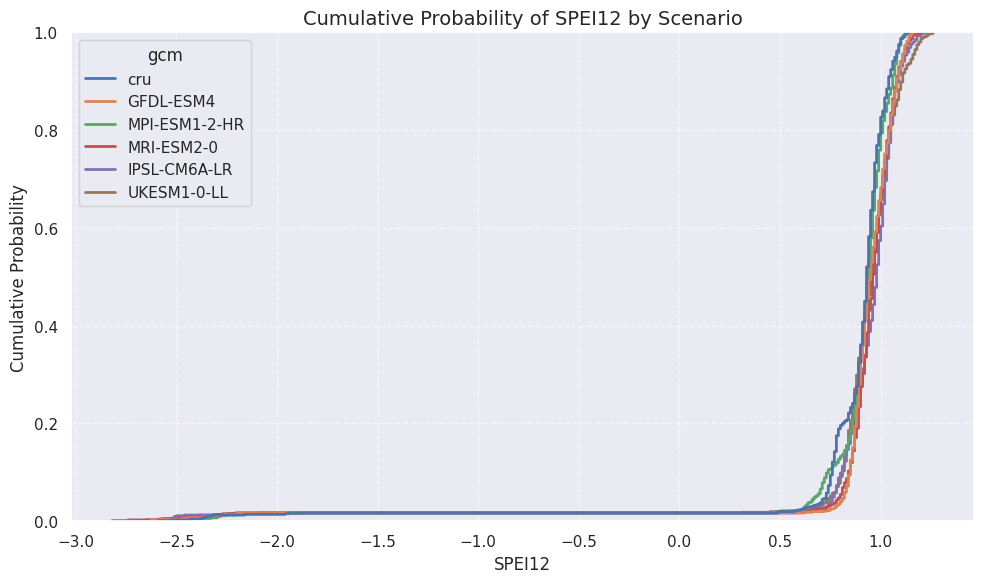

In [5]:
plot_cumulative_spei(df,
                     x_col='spei12',
                     hue_col='gcm'
                     )

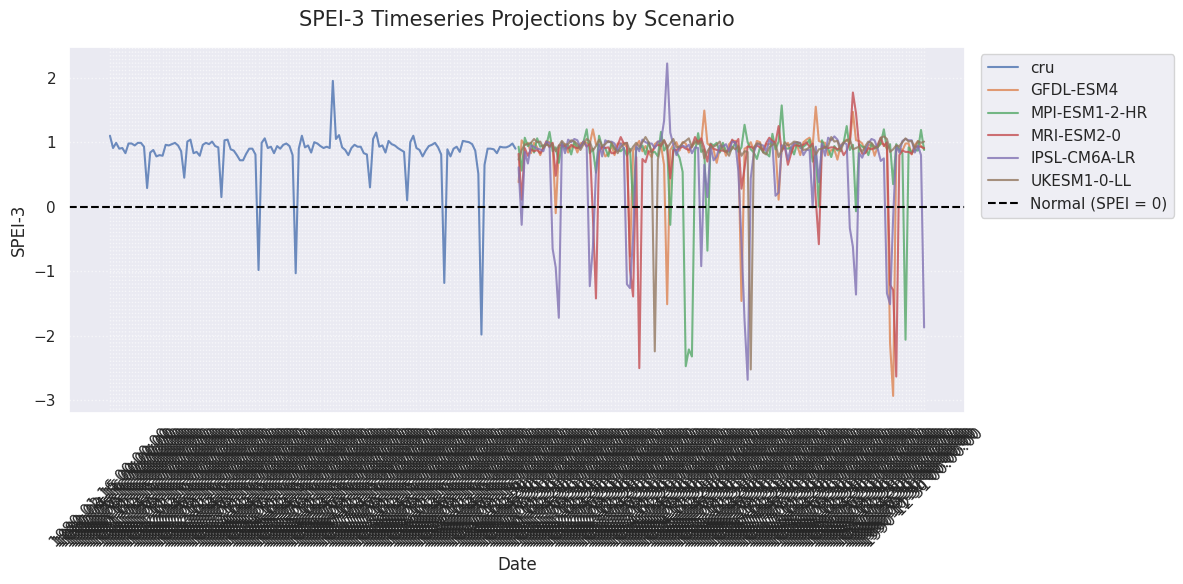

In [7]:
plot_timeseries_spei(df, x_col='date', y_col='spei3', hue_col='gcm', start_year = 1980, end_year = 1990)